# GRU Walk-Forward: Sequential Modeling for Black-Litterman Views

**목적**: 일별 시계열 GRU 모델로 Q(기대수익률)와 Ω(불확실성)를 walk-forward 방식으로 산출  
**구조**: IS=252일(purge 21일 제외 → 실사용 231일) | embargo=21일 | OOS=21일 | step=21일  
**lookback**: T=60일 슬라이딩 윈도우  
**target**: fwd\_ret\_21d (오늘 기준 21거래일 뒤 초과수익률)

In [16]:
# ── 1. Setup ─────────────────────────────────────────────────────────────
import warnings; warnings.filterwarnings("ignore")
import os, gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

# Apple Silicon: use CPU to avoid MPS memory issues
if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    torch.backends.mps.is_available = lambda: False
    torch.backends.mps.is_built     = lambda: False

DEVICE = torch.device("cpu")
print(f"Device: {DEVICE}")

# ── Walk-Forward 파라미터 ──────────────────────────────────────────────────
IS_DAYS      = 252   # IS 설정 (1년)
PURGE_DAYS   = 21    # IS 끝 제거 (레이블 누수 방지)
IS_EFFECTIVE = IS_DAYS - PURGE_DAYS  # = 231
EMBARGO_DAYS = 21    # IS ↔ OOS 공백
OOS_DAYS     = 21    # OOS 예측 구간
STEP_DAYS    = 21    # fold 이동 보폭 (매달 리밸런싱)

# ── Sequential 파라미터 ────────────────────────────────────────────────────
T            = 60    # lookback window (시퀀스 길이)
H            = 21    # horizon (fwd_ret_21d)

# ── 학습 파라미터 ──────────────────────────────────────────────────────────
HIDDEN_SIZE  = 64
NUM_LAYERS   = 2
DROPOUT      = 0.2
BATCH_SIZE   = 256
LR           = 1e-3
MAX_EPOCHS   = 50
PATIENCE     = 5     # early stopping
RANDOM_SEED  = 42

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ── 경로 ──────────────────────────────────────────────────────────────────
BASE_DIR  = os.path.dirname(os.path.abspath(".")) if "__file__" not in dir() else os.path.dirname(os.path.abspath(__file__))
DATA_DIR  = "data/panels"
OUT_DIR   = "data"

# ── Universe: IT 섹터 핵심 10종목 (2016~ 데이터 충분) ─────────────────────
UNIVERSE = ["MSFT", "AAPL", "NVDA", "ADBE", "INTC",
            "AMD",  "QCOM", "TXN",  "CSCO", "IBM"]

# ── 피처: 일별 log 수익률만 사용 (F=1) ───────────────────────────────────
FEATURES   = ["log_ret_1d"]
N_FEATURES = len(FEATURES)  # = 1
print(f"Features ({N_FEATURES}개): {FEATURES}")
print(f"Input shape per sample: (T={T}, F={N_FEATURES})")
print(f"Universe: {UNIVERSE}")

Device: cpu
Features: 17개
Universe: ['MSFT', 'AAPL', 'NVDA', 'ADBE', 'INTC', 'AMD', 'QCOM', 'TXN', 'CSCO', 'IBM']


In [17]:
# ── 2. 데이터 로드 & 전처리 ──────────────────────────────────────────────
def load_daily_panel(universe, data_dir, start_date="2016-01-01", end_date="2025-12-31"):
    """종목별 일별 패널 로드 후 합치기."""
    frames = []
    for ticker in universe:
        path = os.path.join(data_dir, f"{ticker}.csv")
        if not os.path.exists(path):
            print(f"  WARNING: {ticker} not found, skipping")
            continue
        df = pd.read_csv(path, index_col=0, parse_dates=True)
        df.index.name = "date"
        df = df[(df.index >= start_date) & (df.index <= end_date)].copy()
        df["ticker"] = ticker
        frames.append(df)
    panel = pd.concat(frames).sort_index()
    return panel

print("Loading daily panels...")
panel = load_daily_panel(UNIVERSE, DATA_DIR)
print(f"Panel shape: {panel.shape}")
print(f"Date range: {panel.index.min().date()} → {panel.index.max().date()}")
print(f"Tickers: {panel['ticker'].unique().tolist()}")

# ── fwd_ret_21d 레이블 계산 ──────────────────────────────────────────────
def add_fwd_ret(df_ticker: pd.DataFrame, horizon: int = 21) -> pd.DataFrame:
    """종목별 21거래일 선행 초과수익률. (excess over rf)"""
    df = df_ticker.copy()
    if "excess_ret_1d" in df.columns:
        # excess_ret_1d 복리 합산
        log_excess = np.log1p(df["excess_ret_1d"].fillna(0))
        df["fwd_ret_21d"] = log_excess.rolling(horizon).sum().shift(-horizon)
    else:
        log_r = np.log1p(df["log_ret_1d"].fillna(0))
        df["fwd_ret_21d"] = log_r.rolling(horizon).sum().shift(-horizon)
    return df

parts = []
for ticker, grp in panel.groupby("ticker"):
    parts.append(add_fwd_ret(grp, H))
panel = pd.concat(parts).sort_index()

print(f"Label (fwd_ret_21d) stats:")
print(panel["fwd_ret_21d"].describe())

Loading daily panels...
Panel shape: (25130, 63)
Date range: 2016-01-04 → 2025-12-30
Tickers: ['MSFT', 'AMD', 'INTC', 'TXN', 'ADBE', 'CSCO', 'NVDA', 'IBM', 'AAPL', 'QCOM']
Label (fwd_ret_21d) stats:
count    24920.000000
mean         0.017346
std          0.100013
min         -0.616570
25%         -0.036222
50%          0.019073
75%          0.071044
max          0.527823
Name: fwd_ret_21d, dtype: float64


In [18]:
# ── 3. 피처 품질 확인 ───────────────────────────────────────────────────
# 피처 존재 여부
available = [f for f in FEATURES if f in panel.columns]
missing   = [f for f in FEATURES if f not in panel.columns]
print(f"Available features ({len(available)}): {available}")
print(f"Missing features ({len(missing)}): {missing}")

FEATURES = available  # 있는 것만 사용
N_FEATURES = len(FEATURES)

# NaN 비율
nan_ratio = panel[FEATURES].isna().mean().sort_values(ascending=False)
print("NaN ratio (top 10):")
print(nan_ratio.head(10))

# 전처리: 피처 forward-fill (같은 종목 내)
parts = []
for ticker, grp in panel.groupby("ticker"):
    grp = grp.copy()
    grp[FEATURES] = grp[FEATURES].ffill().bfill()
    parts.append(grp)
panel = pd.concat(parts).sort_index()
print(f"After ffill - NaN in features: {panel[FEATURES].isna().sum().sum()}")

Available features (17): ['log_ret_1d', 'mom_1m', 'mom_3m', 'mom_6m', 'vol_20d', 'vol_60d', 'rsi_14', 'bb_pct', 'high52w_ratio', 'ma_gap_20_60', 'autocorr_21d', 'sharpe_21d', 'beta_252d', 'vol_surge', 'vix', 't10y2y', 'indmom']
Missing features (0): []
NaN ratio (top 10):
log_ret_1d       0.0
ma_gap_20_60     0.0
t10y2y           0.0
vix              0.0
vol_surge        0.0
beta_252d        0.0
sharpe_21d       0.0
autocorr_21d     0.0
high52w_ratio    0.0
mom_1m           0.0
dtype: float64
After ffill - NaN in features: 0


In [19]:
# ── 4. 시퀀스 데이터셋 ──────────────────────────────────────────────────
class SequenceDataset(Dataset):
    """Sliding window dataset: X.shape=(T,F), y=scalar."""
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):  return len(self.y)
    def __getitem__(self, i):  return self.X[i], self.y[i]


def build_sequences(df_ticker: pd.DataFrame, feature_cols: list,
                     T: int, scaler: StandardScaler = None,
                     fit_scaler: bool = False):
    """슬라이딩 윈도우로 (N-T, T, F) 시퀀스 생성.
    Returns: X (N-T, T, F), y (N-T,), scaler
    """
    vals   = df_ticker[feature_cols].values.astype(np.float32)  # (N, F)
    labels = df_ticker["fwd_ret_21d"].values.astype(np.float32) # (N,)

    if fit_scaler:
        scaler = StandardScaler()
        # scaler는 IS 전체(T 포함)로 fit — 누수 없음
        scaler.fit(vals)
    vals = scaler.transform(vals)

    Xs, ys = [], []
    for i in range(T, len(vals)):
        # X: [i-T : i] 구간, y: 타임스텝 i의 레이블
        if not np.isnan(labels[i]):
            Xs.append(vals[i-T:i])
            ys.append(labels[i])

    return np.array(Xs), np.array(ys), scaler


def build_oos_sequences(df_ticker: pd.DataFrame, feature_cols: list,
                         T: int, scaler: StandardScaler):
    """OOS 구간: 각 날짜에 대해 직전 T일 시퀀스 생성.
    df_ticker는 (IS+embargo+OOS) 전체를 포함해야 lookback 가능.
    반환: X (N_oos, T, F), dates (N_oos,)
    """
    vals  = df_ticker[feature_cols].values.astype(np.float32)
    vals  = scaler.transform(vals)
    dates = df_ticker.index
    Xs, ds = [], []
    # OOS는 마지막 OOS_DAYS일
    oos_start_idx = len(vals) - OOS_DAYS
    for i in range(oos_start_idx, len(vals)):
        if i >= T:
            Xs.append(vals[i-T:i])
            ds.append(dates[i])
    return np.array(Xs), ds

In [20]:
# ── 5. GRU 모델 ──────────────────────────────────────────────────────────
class GRURegressor(nn.Module):
    """GRU + FC head for return regression."""
    def __init__(self, n_features: int, hidden_size: int = 64,
                 num_layers: int = 2, dropout: float = 0.2):
        super().__init__()
        self.gru = nn.GRU(
            input_size  = n_features,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):              # x: (B, T, F)
        _, h = self.gru(x)             # h: (num_layers, B, hidden)
        out  = self.fc(h[-1])          # 마지막 레이어 hidden → FC
        return out.squeeze(-1)         # (B,)


# 테스트
model_test = GRURegressor(N_FEATURES, HIDDEN_SIZE, NUM_LAYERS, DROPOUT)
dummy = torch.randn(4, T, N_FEATURES)
print("GRU output shape:", model_test(dummy).shape)  # (4,)
print(f"Parameters: {sum(p.numel() for p in model_test.parameters()):,}")

GRU output shape: torch.Size([4])
Parameters: 43,009


In [21]:
# ── 6. 학습 함수 ─────────────────────────────────────────────────────────
def train_gru(X_tr: np.ndarray, y_tr: np.ndarray,
              n_features: int, device: torch.device,
              val_split: float = 0.1) -> GRURegressor:
    """GRU 학습 with early stopping."""
    # train / val 분리 (시계열 순서 유지)
    n_val = max(1, int(len(X_tr) * val_split))
    X_val, y_val = X_tr[-n_val:], y_tr[-n_val:]
    X_tr2, y_tr2 = X_tr[:-n_val], y_tr[:-n_val]

    ds_tr = SequenceDataset(X_tr2, y_tr2)
    ds_vl = SequenceDataset(X_val, y_val)
    dl_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True,  drop_last=False)
    dl_vl = DataLoader(ds_vl, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

    model = GRURegressor(n_features, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3, factor=0.5)
    criterion = nn.MSELoss()

    best_val_loss = float("inf")
    best_state    = None
    wait          = 0

    for epoch in range(MAX_EPOCHS):
        # ── train ──
        model.train()
        for Xb, yb in dl_tr:
            Xb, yb = Xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()

        # ── validate ──
        model.eval()
        with torch.no_grad():
            val_losses = [criterion(model(Xb.to(device)), yb.to(device)).item()
                          for Xb, yb in dl_vl]
        val_loss = np.mean(val_losses)
        sched.step(val_loss)

        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= PATIENCE:
                break

    if best_state:
        model.load_state_dict(best_state)
    return model


def predict_gru(model: GRURegressor, X_oos: np.ndarray,
                device: torch.device) -> np.ndarray:
    """OOS 예측 (배치 처리)."""
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(X_oos), BATCH_SIZE):
            Xb = torch.tensor(X_oos[i:i+BATCH_SIZE], dtype=torch.float32).to(device)
            preds.append(model(Xb).cpu().numpy())
    return np.concatenate(preds)

In [22]:
# ── 7. Walk-Forward 메인 루프 ────────────────────────────────────────────
all_dates  = sorted(panel.index.unique())
total_days = len(all_dates)

# fold 시작점: IS 구간 전체(252일) + embargo(21일) 이후부터
fold_start_min = IS_DAYS + EMBARGO_DAYS  # day index (0-based)

records   = []   # [(fold, ticker, date, y_true, y_pred)]
q_records = []   # [(fold_end_date, ticker, q_val, omega_val)]

fold_idx = 0
idx = fold_start_min  # OOS 첫 날의 날짜 인덱스

print(f"Total trading days: {total_days}")
print(f"First fold OOS start: {all_dates[idx].date() if idx < total_days else 'N/A'}")

while idx + OOS_DAYS <= total_days:
    # ── fold 날짜 경계 ─────────────────────────────────────────────────────
    oos_end_idx   = idx + OOS_DAYS        # exclusive
    oos_start_idx = idx                    # inclusive
    emb_start_idx = oos_start_idx - EMBARGO_DAYS
    is_end_idx    = emb_start_idx          # exclusive (purge 포함)
    is_eff_end    = is_end_idx - PURGE_DAYS
    is_start_idx  = is_eff_end - IS_EFFECTIVE  # = is_end - IS_DAYS

    if is_start_idx < 0:
        idx += STEP_DAYS
        continue

    is_dates  = all_dates[is_start_idx : is_eff_end]     # IS 실사용 231일
    # lookback용: IS + embargo 전체 (scaler 적용 후 OOS lookback에 활용)
    full_dates = all_dates[is_start_idx : oos_end_idx]   # IS+purge+emb+OOS
    oos_dates  = all_dates[oos_start_idx : oos_end_idx]   # OOS 21일

    fold_end_date = oos_dates[-1]

    ticker_preds = {}  # ticker → (y_true_list, y_pred_list)
    ticker_q     = {}  # ticker → q_val
    ticker_omega = {}  # ticker → omega_val

    # ── 종목별 학습 + 예측 ──────────────────────────────────────────────────
    for ticker in UNIVERSE:
        tdf = panel[panel["ticker"] == ticker]

        # IS 실사용 구간
        is_df   = tdf.loc[tdf.index.isin(is_dates)]
        # lookback용 (IS+purge+emb+OOS 전체 — scaler 변환 및 OOS 시퀀스 빌드)
        full_df = tdf.loc[tdf.index.isin(full_dates)]

        if len(is_df) < T + 10 or len(full_df) < T + OOS_DAYS:
            continue

        try:
            # IS 슬라이딩 윈도우
            X_tr, y_tr, scaler = build_sequences(is_df, FEATURES, T, fit_scaler=True)
            if len(X_tr) < 10:
                continue

            # GRU 학습
            model = train_gru(X_tr, y_tr, N_FEATURES, DEVICE)

            # OOS 예측 (full_df 사용 — lookback이 IS를 참조)
            X_oos, oos_date_list = build_oos_sequences(full_df, FEATURES, T, scaler)
            if len(X_oos) == 0:
                continue

            y_hat = predict_gru(model, X_oos, DEVICE)

            # ground truth (사용 가능한 것만)
            oos_tdf = tdf.loc[tdf.index.isin(oos_date_list)]
            y_true  = oos_tdf["fwd_ret_21d"].values

            for d, yh, yt in zip(oos_date_list, y_hat, y_true):
                records.append((fold_idx, ticker, d, float(yt), float(yh)))

            # Q: OOS 21일 예측의 평균
            q_val    = float(np.nanmean(y_hat))
            # Omega: 잔차 분산 (y_true가 있는 날만)
            valid    = ~np.isnan(y_true)
            if valid.sum() > 1:
                residuals = y_true[valid] - y_hat[:valid.sum()]
                omega_val = float(np.var(residuals))
            else:
                omega_val = float(np.var(y_hat))

            ticker_q[ticker]     = q_val
            ticker_omega[ticker] = omega_val

            del model; gc.collect()

        except Exception as e:
            print(f"  [WARN] fold {fold_idx} {ticker}: {e}")
            continue

    # fold Q/Omega 기록
    for tk in ticker_q:
        q_records.append({
            "date":   fold_end_date,
            "ticker": tk,
            "q":      ticker_q[tk],
            "omega":  ticker_omega[tk],
        })

    fold_idx += 1
    idx      += STEP_DAYS

    if fold_idx % 5 == 0:
        print(f"  Fold {fold_idx:3d} | OOS end: {fold_end_date.date()} | "
              f"tickers done: {len(ticker_q)}")

print(f"Done! Total folds: {fold_idx}, records: {len(records)}, Q-records: {len(q_records)}")

Total trading days: 2513
First fold OOS start: 2017-02-02
  Fold   5 | OOS end: 2017-07-03 | tickers done: 10
  Fold  10 | OOS end: 2017-11-30 | tickers done: 10
  Fold  15 | OOS end: 2018-05-03 | tickers done: 10
  Fold  20 | OOS end: 2018-10-02 | tickers done: 10
  Fold  25 | OOS end: 2019-03-06 | tickers done: 10
  Fold  30 | OOS end: 2019-08-05 | tickers done: 10
  Fold  35 | OOS end: 2020-01-03 | tickers done: 10
  Fold  40 | OOS end: 2020-06-04 | tickers done: 10
  Fold  45 | OOS end: 2020-11-02 | tickers done: 10
  Fold  50 | OOS end: 2021-04-06 | tickers done: 10
  Fold  55 | OOS end: 2021-09-02 | tickers done: 10
  Fold  60 | OOS end: 2022-02-02 | tickers done: 10
  Fold  65 | OOS end: 2022-07-06 | tickers done: 10
  Fold  70 | OOS end: 2022-12-02 | tickers done: 10
  Fold  75 | OOS end: 2023-05-05 | tickers done: 10
  Fold  80 | OOS end: 2023-10-05 | tickers done: 10
  Fold  85 | OOS end: 2024-03-07 | tickers done: 10
  Fold  90 | OOS end: 2024-08-07 | tickers done: 10
  Fold

Total OOS samples: 22190
=== OOS Performance ===
  IC (mean):  -0.0271
  IC (std):   0.3471
  ICIR:       -0.0779
  IC > 0:     47.9%
  R² (OOS):   -0.8381


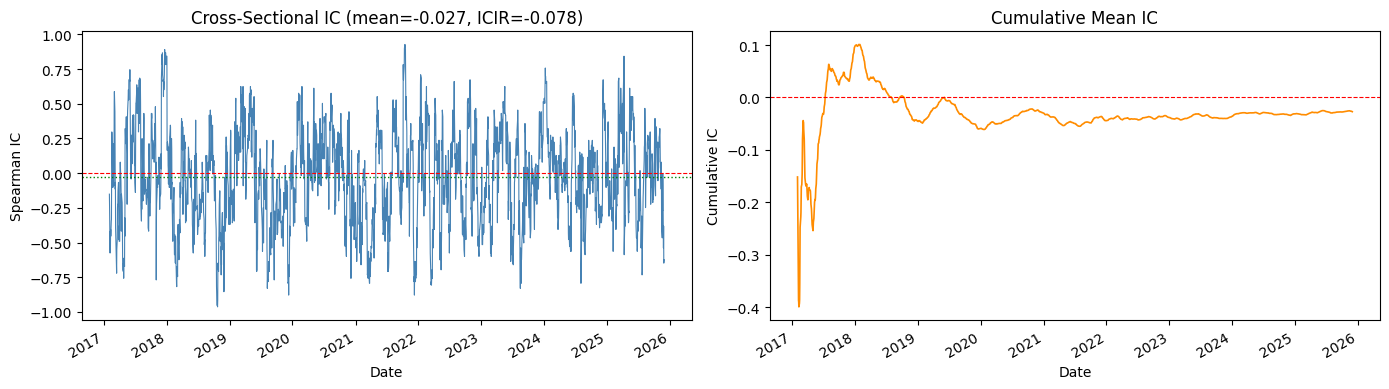

Plot saved.


In [23]:
# ── 8. OOS 성능 평가 (IC / ICIR / R²) ──────────────────────────────────
results_df = pd.DataFrame(records, columns=["fold","ticker","date","y_true","y_pred"])
results_df = results_df.dropna(subset=["y_true","y_pred"])
print(f"Total OOS samples: {len(results_df)}")

# ── IC (Spearman 상관) — 날짜별 횡단면 IC ─────────────────────────────
def cross_ic(df: pd.DataFrame) -> pd.Series:
    ic_by_date = {}
    for date, grp in df.groupby("date"):
        if len(grp) >= 2:
            rho, _ = spearmanr(grp["y_true"], grp["y_pred"])
            ic_by_date[date] = rho
    return pd.Series(ic_by_date)

ic_series = cross_ic(results_df)
ic_mean   = ic_series.mean()
ic_std    = ic_series.std()
icir      = ic_mean / ic_std if ic_std > 0 else np.nan
r2        = r2_score(results_df["y_true"], results_df["y_pred"])

print(f"=== OOS Performance ===")
print(f"  IC (mean):  {ic_mean:.4f}")
print(f"  IC (std):   {ic_std:.4f}")
print(f"  ICIR:       {icir:.4f}")
print(f"  IC > 0:     {(ic_series > 0).mean()*100:.1f}%")
print(f"  R² (OOS):   {r2:.4f}")

# IC 시계열 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ic_series.plot(ax=axes[0], title=f"Cross-Sectional IC (mean={ic_mean:.3f}, ICIR={icir:.3f})",
               color="steelblue", linewidth=0.8)
axes[0].axhline(0, color="red", linestyle="--", linewidth=0.8)
axes[0].axhline(ic_mean, color="green", linestyle=":", linewidth=1)
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Spearman IC")

ic_series.expanding().mean().plot(ax=axes[1], title="Cumulative Mean IC",
                                   color="darkorange", linewidth=1.2)
axes[1].axhline(0, color="red", linestyle="--", linewidth=0.8)
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Cumulative IC")

plt.tight_layout()
plt.savefig("data/gru_ic_plot.png", dpi=100)
plt.show()
print("Plot saved.")

In [24]:
# ── 9. Q / Ω 저장 ───────────────────────────────────────────────────────
q_df = pd.DataFrame(q_records)  # columns: date, ticker, q, omega
q_df = q_df.set_index(["date", "ticker"]).sort_index()

# Q: pivot to (date × ticker)
Q_pivot = q_df["q"].unstack("ticker")
O_pivot = q_df["omega"].unstack("ticker")

print("Q matrix shape:", Q_pivot.shape)
print("Q sample:")
print(Q_pivot.tail(3))

# ── Cross-sectional z-score 표준화 (BL 입력 전처리) ─────────────────────
# 날짜별로 Q를 z-score → pi(시장 균형 수익률) 스케일로 복원
# 이는 BL notebook에서 수행하지만 여기서 미리 저장해둠
Q_pivot.to_parquet(os.path.join(OUT_DIR, "Q_gru.parquet"))
O_pivot.to_parquet(os.path.join(OUT_DIR, "Omega_gru.parquet"))

print(f"Saved:")
print(f"  data/Q_gru.parquet     shape={Q_pivot.shape}")
print(f"  data/Omega_gru.parquet shape={O_pivot.shape}")

# 요약
print(f"=== 최종 요약 ===")
print(f"  Walk-forward folds: {fold_idx}")
print(f"  Date range: {Q_pivot.index.min().date()} → {Q_pivot.index.max().date()}")
print(f"  Universe: {Q_pivot.columns.tolist()}")
print(f"  IC: {ic_mean:.4f} | ICIR: {icir:.4f} | R²: {r2:.4f}")

Q matrix shape: (106, 10)
Q sample:
ticker          AAPL      ADBE       AMD      CSCO       IBM      INTC  \
date                                                                     
2025-10-09 -0.014895 -0.096899  0.026601  0.061044 -0.038699 -0.178573   
2025-11-07  0.122767 -0.085182  0.115352  0.048660 -0.026492  0.106823   
2025-12-09  0.069641 -0.012494  0.123207  0.008889 -0.001778 -0.022473   

ticker          MSFT      NVDA      QCOM       TXN  
date                                                
2025-10-09 -0.079667  0.099880 -0.059436  0.111955  
2025-11-07  0.010120 -0.030895  0.033208  0.004931  
2025-12-09  0.033752 -0.034855  0.018445  0.038058  
Saved:
  data/Q_gru.parquet     shape=(106, 10)
  data/Omega_gru.parquet shape=(106, 10)
=== 최종 요약 ===
  Walk-forward folds: 106
  Date range: 2017-03-03 → 2025-12-09
  Universe: ['AAPL', 'ADBE', 'AMD', 'CSCO', 'IBM', 'INTC', 'MSFT', 'NVDA', 'QCOM', 'TXN']
  IC: -0.0271 | ICIR: -0.0779 | R²: -0.8381
